## Hyperliquid_Trader_Analysis By Srijan Roy
Project Overview

This project analyzes how Bitcoin market sentiment (Fear & Greed Index) influences trader behavior and trading performance on Hyperliquid.

The analysis combines historical trader data with daily Bitcoin market sentiment to identify behavioral changes, profitability trends, trader segments, and actionable trading strategies.

Additionally, K-Means clustering was applied to identify distinct trader archetypes based on their trading behavior.

### IMPORTING LIBRARIES

#### Importing Required Libraries
In this section, we import all necessary Python libraries for:
- data manipulation
- visualization
- statistical analysis

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)

# Data Preparation

#### UPLOAD DATASETS IN GOOGLE COLAB

In [56]:
sentiment = pd.read_csv("fear_greed_index.csv")

trader = pd.read_csv("historical_data.csv")

##### Previewing the data

In [57]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [58]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


##### Checking The Dimensions


In [59]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trader.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


###### Insight:
- The Bitcoin Market Sentiment(Fear/Greed) dataset contains 2644 rows and 4 columns
- The Historical Trader Dataset contains 211224 rows and 16 columns

##### Checking for column names

In [60]:
print(sentiment.columns)
print(trader.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


##### Checking for missing values

In [61]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [62]:
print(trader.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


###### Insight: Both dataset contains no missing values

##### Checking for duplicates

In [63]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Sentiment Duplicates: 0


In [64]:
print("Trader Duplicates:", trader.duplicated().sum())

Trader Duplicates: 0


###### Insight: Both dataset contains no duplicate rows

##### Summary Stats

In [65]:
sentiment.describe(include='all')

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [66]:
trader.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


##### Checking for categorical values



In [67]:
sentiment["classification"].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [68]:
trader["Side"].value_counts()

,count
Side,
SELL,108528
BUY,102696


In [69]:
trader["Direction"].value_counts()

,count
Direction,
Open Long,49895
Close Long,48678
Open Short,39741
Close Short,36013
Sell,19902
Buy,16716
Spot Dust Conversion,142
Short > Long,70
Long > Short,57


##### Checking for data types

In [70]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [71]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Data Cleaning

##### Converting dates in both datasets and creating a common date column for both

In [72]:
trader["Timestamp IST"] = pd.to_datetime(
    trader["Timestamp IST"],
    format="%d-%m-%Y %H:%M")

In [73]:
trader["Date"] = trader["Timestamp IST"].dt.date ### common date column

In [74]:
sentiment["date"] = pd.to_datetime(sentiment["date"]) ### for sentiment column

In [75]:
sentiment["Date"] = sentiment["date"].dt.date ### creating a common date column

#### Cheking for Date Ranges in Both dataset

In [76]:
print("Trader Date Range") ###for trader ds
print(trader["Date"].min())
print(trader["Date"].max())

Trader Date Range
2023-05-01
2025-05-01


In [77]:
print("Sentiment Date Range")   ### for sentiment ds
print(sentiment["Date"].min())
print(sentiment["Date"].max())

Sentiment Date Range
2018-02-01
2025-05-02


#### Merging both datasets

In [78]:
merged = pd.merge(
    trader,
    sentiment[["Date","classification","value"]],
    on="Date",
    how="left"
)

In [79]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [80]:
print(merged.shape) ### checking if the merge is sucessful
print(merged[["Date", "classification", "value"]].head())

(211224, 19)
         Date classification  value
0  2024-12-02  Extreme Greed   80.0
1  2024-12-02  Extreme Greed   80.0
2  2024-12-02  Extreme Greed   80.0
3  2024-12-02  Extreme Greed   80.0
4  2024-12-02  Extreme Greed   80.0


### Creating the key metrics

#### Metric 1: Daily PnL per Trader/Account

In [81]:
daily_pnl = (
    merged
    .groupby(["Date", "Account"])["Closed PnL"]
    .sum()
    .reset_index())


In [82]:
daily_pnl.head(15)

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.982785
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.538612
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.732282
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,537.211402


Insights: Each row represents a trader's total profit/loss for that day.

#### Metric 2: Win Rate

In [83]:
merged["Win"] = merged["Closed PnL"] > 0 ### creating a flag

In [84]:
#### winrate for each trader
win_rate = (
    merged
    .groupby("Account")["Win"]
    .mean()
    .reset_index())

win_rate.rename(columns={"Win": "Win Rate"}, inplace=True)

win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


Insights: A 'winning trade' is just a trade with positive Closed PnL

#### Metric 3: Average Trade Size

In [85]:
avg_trade_size = (
    merged
    .groupby("Account")["Size USD"]
    .mean()
    .reset_index())

avg_trade_size.rename(columns={"Size USD":"Average Trade Size"}, inplace=True)

avg_trade_size.head()

,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


#### Metric 4: Number of Trades per Day

In [86]:
trades_per_day = (
    merged
    .groupby("Date")
    .size()
    .reset_index(name="Trade Count"))

trades_per_day.head(15)

,Date,Trade Count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
5,2023-12-17,14
6,2023-12-18,2
7,2023-12-19,15
8,2023-12-20,18
9,2023-12-21,49


Insights: This tells how active the market was each day.

#### Metric 5: Long / Short Ratio

In [109]:
merged["TradeType"] = merged["Direction"].map({
    "Open Long": "Long",
    "Close Long": "Long",
    "Open Short": "Short",
    "Close Short": "Short"
})

In [110]:
long_short = merged.dropna(subset=["TradeType"])

In [111]:
long_short_sentiment = (
    long_short
    .groupby(["classification", "TradeType"])
    .size()
    .unstack(fill_value=0)
)

long_short_sentiment

TradeType,Long,Short
classification,,
Extreme Fear,13246,6291
Extreme Greed,13486,14160
Fear,35084,20108
Greed,16542,22986
Neutral,20215,12203


In [88]:
merged["Direction"].value_counts() ### taking this one for long/short ratio as it contains values like open long/open short

,count
Direction,
Open Long,49895
Close Long,48678
Open Short,39741
Close Short,36013
Sell,19902
Buy,16716
Spot Dust Conversion,142
Short > Long,70
Long > Short,57


In [89]:
long_trades = merged["Direction"].isin(["Open Long", "Close Long"]).sum() ## merging both open long and close long together

short_trades = merged["Direction"].isin(["Open Short", "Close Short"]).sum() ## same as before but this time were doing it for short

print("Long Trades :", long_trades)
print("Short Trades:", short_trades)

print(f"Long/Short Ratio = {long_trades/short_trades:.2f}")

Long Trades : 98573
Short Trades: 75754
Long/Short Ratio = 1.30


Insights: The overall long/short ratio 1.30

### **Note: The provided trader dataset does not contain a leverage column, despite it being referenced in the project description. Therefore, leverage-based analysis could not be performed. The analysis focuses on the available behavioral metrics such as PnL, trade frequency, position size, and trading direction.

# Analysis

### Question 1 - Does performance differ between Fear vs Greed days?


#### Checking if the average PnL differ between Fear vs Greed days

In [90]:
pnl_by_sentiment = (
    merged
    .groupby("classification")["Closed PnL"]
    .mean()
    .reset_index())

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


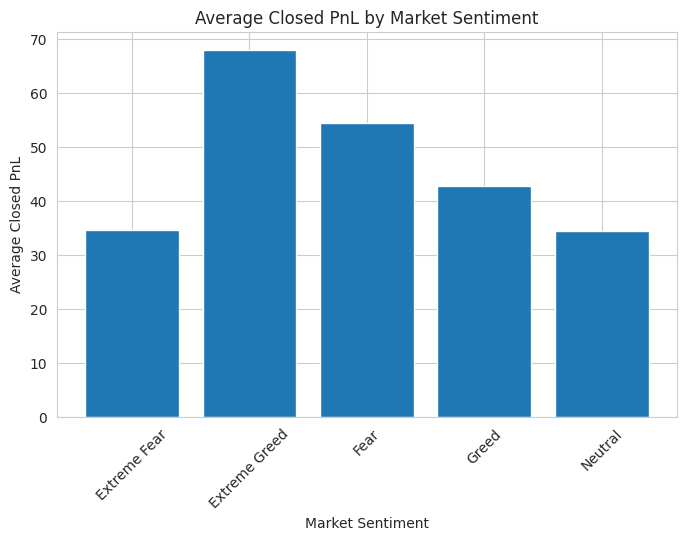

In [91]:
### ploting the fig
plt.figure(figsize=(8,5))

plt.bar(
    pnl_by_sentiment["classification"],
    pnl_by_sentiment["Closed PnL"]
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.show()

Insights:
- Observation 1: Extreme Greed days had the highest average Closed PnL (67.89).    
This suggests that on avg, traders realized larger profits during periods of very positive market sentiment.

- Observation 2: Fear days (54.29) also showed relatively strong profitability.                                                               
It suggests traders may have been able to capitalize on market volatility during fearful conditions.
- Observation 3: Neutral and Extreme Fear had the lowest average PnL.
This indicates profitability wasn't simply increasing or decreasing with sentiment.

**Note: A few highly profitable trades can increase the average, so we probably shouldn't conclude that 'all traders made more money during Extreme Greed'.

#### Comparing Win Rate by Sentiment(Fear/Greed days)

In [93]:
win_rate_sentiment = (
    merged
    .groupby("classification")["Win"]
    .mean()
    .reset_index()
)

win_rate_sentiment["Win"] *= 100

win_rate_sentiment

,classification,Win
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


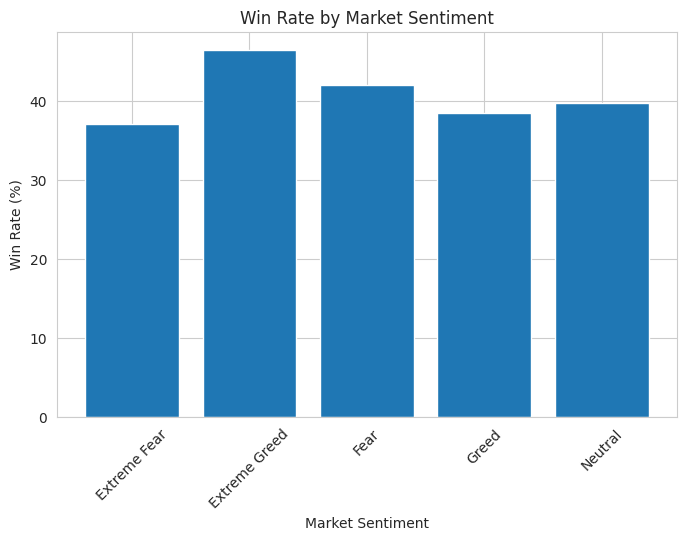

In [94]:
plt.figure(figsize=(8,5))

plt.bar(
    win_rate_sentiment["classification"],
    win_rate_sentiment["Win"]
)

plt.title("Win Rate by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()

Insights:
- Observation 1: Extreme Greed days recorded the highest win rate (46.49%).
This indicates that traders experienced most profitable trades during periods of very positive market sentiment.
- Observation 2: Fear days achieved the second-highest win rate (42.08%).
Although lower than Extreme Greed, traders still performed relatively well during Fear periods.
- Observation 3: Extreme Fear days had the lowest win rate (37.06%).
This suggests that highly pessimistic market conditions were associated with fewer profitable trades, making them comparatively more challenging for traders.
- Observation 4: The difference in win rates across sentiment categories is moderate rather than extreme.
The gap between the highest (46.49%) and lowest (37.06%) win rates is approximately 9.4 percentage points, indicating that while sentiment appears to influence trading success, it is unlikely to be the sole factor determining profitability.

#### Comparing Drawdown proxy by Sentiment

In [95]:
merged["Loss"] = merged["Closed PnL"].apply(lambda x: x if x < 0 else 0) ### creating a column for losing trades

In [96]:
### summarizing it by sentiment:
drawdown_proxy = (
    merged.groupby("classification")
    .agg(
        Avg_Loss=("Loss", "mean"),
        Worst_Loss=("Loss", "min"),
        Total_Loss=("Loss", "sum")
    )
    .reset_index()
)

drawdown_proxy

,classification,Avg_Loss,Worst_Loss,Total_Loss
0,Extreme Fear,-29.734653,-31036.69194,-6.363216e+05
1,Extreme Greed,-6.773853,-10259.46800,-2.708999e+05
2,Fear,-9.599331,-35681.74723,-5.935938e+05
3,Greed,-21.046179,-117990.10410,-1.058686e+06
4,Neutral,-10.329716,-24500.00000,-3.892857e+05


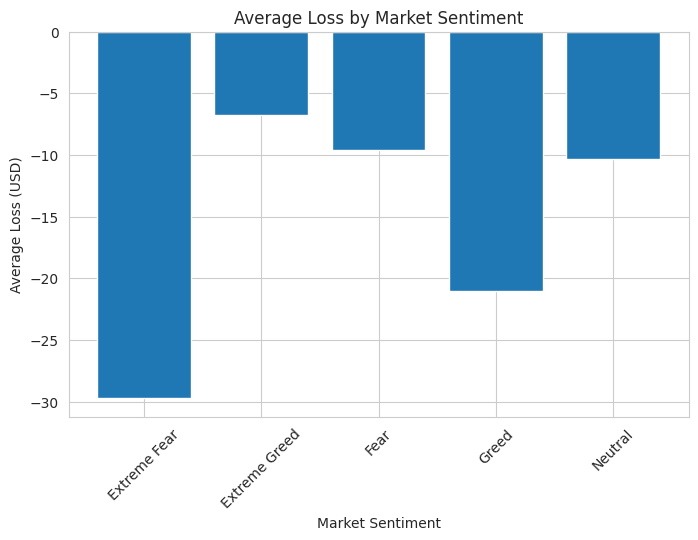

In [98]:
plt.figure(figsize=(8,5))

plt.bar(drawdown_proxy["classification"], drawdown_proxy["Avg_Loss"])

plt.title("Average Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Loss (USD)")

plt.xticks(rotation=45)

plt.show()

insights:
- Observation 1: Extreme Fear recorded the highest average loss (-29.73 USD per trade). This indicates that losing trades during periods of extreme market pessimism were generally more severe than under other sentiment conditions.
- Observation 2: Extreme Greed had the smallest average loss (-6.77 USD per trade).Although losses still occurred, they were considerably smaller on average during Extreme Greed periods.
- Observation 3: Greed accumulated the largest total realized losses (-1.06 million USD). This was the highest aggregate loss among all sentiment categories. The result suggests that traders either traded more frequently or took larger positions during Greed periods, leading to greater overall downside exposure.
- Observation 4: The largest single losing trade occurred during Greed (-117,990.10 USD). This highlights that optimistic market conditions may encourage higher-risk trading, which can occasionally result in substantial individual losses despite favorable average performance.
- Observation 5: Loss severity varied noticeably across different market sentiments.

Question 1

Conclusions :
- The analysis indicates that trader performance differs across market sentiment categories. Trades executed during Extreme Greed exhibited the highest average profitability (67.89 USD), the highest win rate (46.49%), and the lowest average loss (-6.77 USD), suggesting the strongest overall performance under highly optimistic market conditions.

- In contrast, Extreme Fear was associated with the weakest performance, characterized by the lowest win rate (37.06%) and the highest average loss (-29.73 USD), indicating increased downside risk.

- Interestingly, Fear days still produced relatively strong average profitability, implying that periods of elevated market uncertainty may create profitable opportunities for traders who manage risk effectively.

- Overall, the results suggest that market sentiment is associated with both trader profitability and downside risk, although sentiment alone does not fully explain trading performance.

### Question 2 - Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


#### Trade frequency by sentiment (to see if the trader changes behaviour during the extreme periods)

In [99]:
### creating trade freq
trade_frequency = (
    merged.groupby("classification")
    .size()
    .reset_index(name="Number of Trades")
)

trade_frequency

,classification,Number of Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


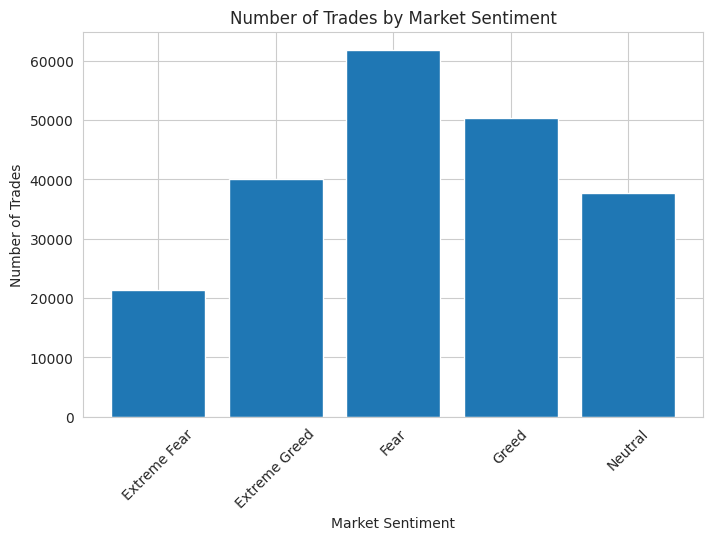

In [101]:
### ploting trade freq
plt.figure(figsize=(8,5))

plt.bar(
    trade_frequency["classification"],
    trade_frequency["Number of Trades"]
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

Insights:
- Observation 1: Fear recorded the highest trading activity with 61,837 trades. This suggests that traders were most active during periods of market fear, indicating that increased market uncertainty may encourage traders to seek opportunities arising from higher price volatility.
- Observation 2: Extreme Fear had the lowest trading activity (21,400 trades). This may reflect a more cautious approach or reduced confidence under highly uncertain market conditions.
- Observation 3: Greed and Extreme Greed also experienced substantial trading activity. With 50,303 and 39,992 trades respectively, optimistic market conditions continued to attract considerable participation suggesting that traders remained actively engaged during bullish phases.



**Note - Market sentiment appears to influence trading activity. Moderate fear was associated with the highest market participation, suggesting that traders actively seek opportunities during volatile conditions. However, participation declined during Extreme Fear, indicating that excessive uncertainty may discourage trading.


#### Trader behaviour during avg trade size/ position size


In [102]:
trade_size = (
    merged.groupby("classification")["Size USD"]
    .mean()
    .reset_index())

trade_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


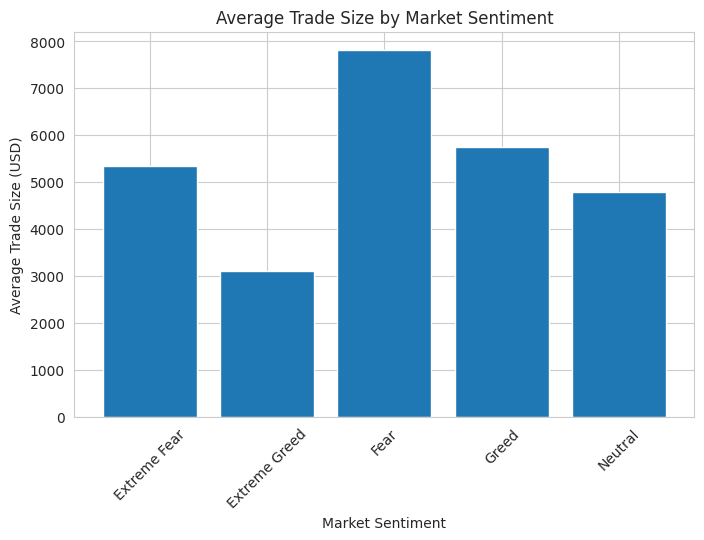

In [103]:
plt.figure(figsize=(8,5))

plt.bar(
    trade_size["classification"],
    trade_size["Size USD"]
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

Insights:
- Observation 1: Fear recorded the largest average trade size (7,816.11 USD).This indicates that traders committed larger amounts of capital per trade during Fear periods. The result suggests that traders may have been attempting to capitalize on increased market volatility or perceived buying opportunities.
- Observation 2: Extreme Greed had the smallest average trade size (3,112.25 USD).Despite producing the highest average PnL and win rate, traders executed comparatively smaller trades during Extreme Greed. This suggests that stronger performance was not necessarily driven by larger position sizes.
- Observation 3: Greed and Extreme Fear exhibited moderate average trade sizes. With average trade sizes of 5,736.88 USD and 5,349.73 USD, traders maintained moderate levels of capital exposure under both optimistic and highly pessimistic market conditions.

**Note - Periods of market Fear were associated with both the highest trading activity and the largest average trade sizes. This suggests that traders were more aggressive during fearful market conditions, potentially attempting to exploit heightened volatility and price dislocations.

#### Long/Short bias

In [113]:
long_short_sentiment["Long/Short Ratio"] = (
    long_short_sentiment["Long"] /
    long_short_sentiment["Short"]
)

long_short_sentiment.reset_index(inplace=True)

long_short_sentiment


TradeType,index,classification,Long,Short,Long/Short Ratio
0,0,Extreme Fear,13246,6291,2.105548
1,1,Extreme Greed,13486,14160,0.952401
2,2,Fear,35084,20108,1.744778
3,3,Greed,16542,22986,0.719655
4,4,Neutral,20215,12203,1.656560


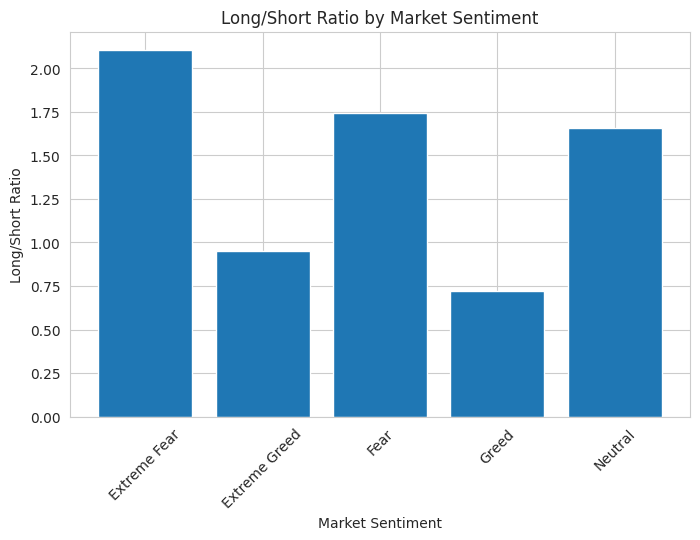

In [115]:
plt.figure(figsize=(8,5))

plt.bar(
    long_short_sentiment["classification"],
    long_short_sentiment["Long/Short Ratio"]
)

plt.title("Long/Short Ratio by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long/Short Ratio")

plt.xticks(rotation=45)

plt.show()


Insights:
- Observation 1: Extreme Fear recorded the highest Long/Short Ratio (2.11). This indicates that traders opened and closed significantly more long positions than short positions during periods of extreme market pessimism.
- Observation 2: Fear also exhibited a strong long bias, with a Long/Short Ratio of 1.74.
- Observation 3: Greed recorded the lowest Long/Short Ratio (0.72).Unlike Fear periods, traders executed substantially more short positions than long positions during Greed. This suggests that many participants anticipated price corrections after strong market advances and positioned themselves accordingly.
- Observation 4: Extreme Greed displayed a nearly balanced market bias (Long/Short Ratio = 0.95). The almost equal number of long and short trades indicates that trader sentiment was more evenly divided under extremely optimistic market conditions, with no strong directional preference.

**Note - Traders tended to increase long exposure during Fear and Extreme Fear, suggesting they attempted to buy into market weakness. In contrast, Greed periods were associated with greater short positioning, indicating that traders were more likely to anticipate profit-taking or price reversals after sustained market optimism.

Question 2

Conclutions:
- Trader behavior varied considerably across different market sentiment conditions.
- Fear periods were characterized by the highest trading activity and the largest average trade sizes, indicating increased market participation and greater capital commitment during uncertain conditions.
- Additionally, traders exhibited a strong long bias during Fear and Extreme Fear, suggesting that many participants viewed market declines as buying opportunities.
- Conversely, Greed periods showed a relatively stronger preference for short positions, indicating expectations of potential price corrections after bullish market movements.
- Overall, the findings demonstrate that market sentiment influences not only trading performance but also trading behavior, including participation levels, position sizing, and directional bias.

### Question 3- Identify 2-3 Trader Segments

#### Segment 1 - Frequent vs Infrequent Traders

In [116]:
### Counting trades per account
trade_count = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Total_Trades")
)

trade_count.head()

,Account,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [118]:
### median
median_trades = trade_count["Total_Trades"].median()

print(median_trades)

3699.0


In [119]:
### creating the segment
trade_count["Trader_Type"] = trade_count["Total_Trades"].apply(
    lambda x: "Frequent Trader"
    if x >= median_trades
    else "Infrequent Trader")

trade_count.head()

,Account,Total_Trades,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [120]:
### comparing profitablity
account_pnl = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .reset_index())

segment1 = trade_count.merge(account_pnl,on="Account")

segment1.groupby("Trader_Type")["Closed PnL"].mean()

,Closed PnL
Trader_Type,
Frequent Trader,496527.661215
Infrequent Trader,147032.272750


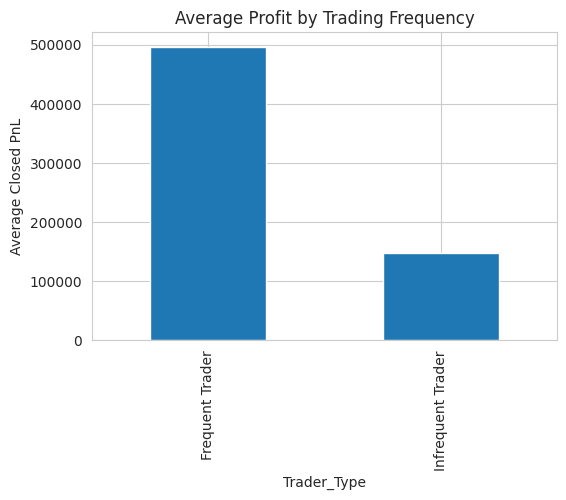

In [121]:
###plotting the results
segment1.groupby("Trader_Type")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Profit by Trading Frequency")

plt.ylabel("Average Closed PnL")

plt.show()

Insights:
- Observation 1: Frequent Traders achieved substantially higher average profitability than Infrequent Traders. On average, Frequent Traders generated 496,527.66 USD in total realized PnL, compared with 147,032.27 USD for Infrequent Traders. This suggests that higher trading activity was associated with stronger overall profitability in this dataset.
- Observation 2: Frequent Traders earned approximately 3.4 times more profit than Infrequent Traders. The large difference in average realized PnL indicates that traders who participated in the market more actively generally accumulated greater profits over the observed period.
- Observation 3: Greater market participation appears to be associated with improved trading performance.

**Note - Active participation was associated with higher cumulative profitability. Traders who engaged more frequently in the market generated significantly greater total realized profits, suggesting that consistent market participation may provide more opportunities to capitalize on favorable price movements.

#### Segment 2 - Consistent Winners vs Inconsistent Traders

In [122]:
account_winrate = (                   ### using the winrate
    merged.groupby("Account")["Win"]
    .mean()
    .reset_index())

account_winrate["Win"] *= 100

In [123]:
median_win = account_winrate["Win"].median()

print(median_win)

39.196804118723136


In [124]:
### creating groups
account_winrate["Performance"] = account_winrate["Win"].apply(
    lambda x:
    "Consistent Winner"
    if x >= median_win
    else "Inconsistent Trader")

In [125]:
### comparing profitability
segment2 = account_winrate.merge(account_pnl,on="Account")

segment2.groupby("Performance")["Closed PnL"].mean()

,Closed PnL
Performance,
Consistent Winner,296760.268498
Inconsistent Trader,346799.665467


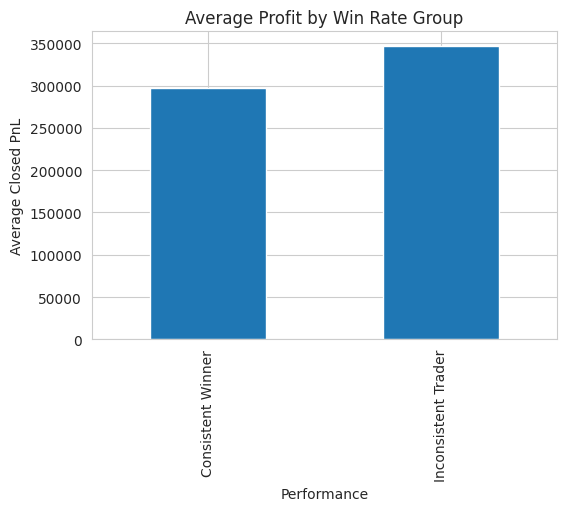

In [126]:
### ploting the results
segment2.groupby("Performance")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(6,4))

plt.title("Average Profit by Win Rate Group")

plt.ylabel("Average Closed PnL")

plt.show()

Insights:
- Observation 1: Inconsistent Traders generated a higher average total realized PnL (346,799.67 USD) than Consistent Winners (296,760.27 USD).
- Observation 2: A higher win rate did not necessarily translate into higher profitability.
- Observation 3: Profitability appears to depend on both win rate and trade outcomes.

**Note - The analysis demonstrates that a higher win rate does not automatically result in higher profitability. In this dataset, traders with lower win rates achieved greater average realized PnL, suggesting that trade quality and the size of winning positions can be more important than simply increasing the proportion of winning trades.

#### Segment 3 - High Profit vs Low Profit Traders

In [127]:
### total pnl
profit_segment = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .reset_index())

In [128]:
median_profit = profit_segment["Closed PnL"].median()

print(median_profit)

117655.079453


In [129]:
### creating groups
profit_segment["Profit_Group"] = profit_segment["Closed PnL"].apply(
    lambda x:
    "High Profit"
    if x >= median_profit
    else "Low Profit")

In [130]:
### comparing trade size
account_trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index()
)

segment3 = profit_segment.merge(account_trade_size,on="Account")

segment3.groupby("Profit_Group")["Size USD"].mean()

,Size USD
Profit_Group,
High Profit,7516.888197
Low Profit,4498.970543


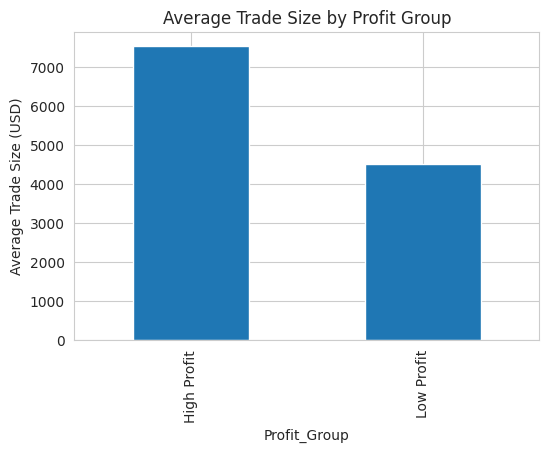

In [132]:
### ploting the results
segment3.groupby("Profit_Group")["Size USD"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Trade Size by Profit Group")

plt.ylabel("Average Trade Size (USD)")

plt.show()

Insights:
- Observation 1: High Profit Traders executed significantly larger trades on average (7,516.89 USD) than Low Profit Traders (4,498.97 USD).
- Observation 2: High Profit Traders traded with approximately 67% larger position sizes than Low Profit Traders.

**Note - Higher-profit traders tended to commit more capital per trade, indicating that position sizing was associated with stronger trading performance in this dataset.

# Actionable Output

##### Strategy Recommendation 1 :
### I would suggest to trade more selectively during **Extreme Fear**


Reasoning: My analysis showed the **Win Rate** is at **lowest** and **Average Loss** is at **highest** during this period. So, I would suggest traders to prioritize capital preservation by reducing position sizes and avoiding excessive trading activity. Since **downside risk** was highest during these periods, adopting stricter risk management practices such as tighter stop-loss levels and more selective trade entries may help limit losses.

##### Strategy Recommendation 2 :
### I would suggest to Increase exposure during **Extreme Greed** but maintain discipline

Reasoning: From my analysis I've found out during this period the **Average PnL** is at the **highest**, the **Win Rate** is also at the highest, and
the **Average Loss** is at **lowest**. So, therefore I'd suggest traders to consider maintaining normal or moderately increased market exposure, as these conditions were associated with stronger average profitability and higher win rates. However, risk controls should remain in place to guard against sudden market reversals.

##### Strategy Recommendation 3 :
### Rather than maximizing win rate, traders should focus on improving **risk-reward** efficiency.

Reasoning: From my analysis I've found out **Higher Win Rate ≠ Higher Profit**. The analysis indicates that traders with lower win rates were still capable of generating higher overall profits suggesting that allowing profitable trades to run while controlling losses may be more effective than simply increasing the percentage of winning trades.

## Clustering traders into behavioral archetypes

In [133]:
### Creating the Trader Features
trader_features = (
    merged.groupby("Account")
    .agg(
        Total_Trades=("Account", "count"),
        Average_Trade_Size=("Size USD", "mean"),
        Total_PnL=("Closed PnL", "sum"),
        Win_Rate=("Win", "mean")
    )
    .reset_index())

trader_features["Win_Rate"] *= 100

trader_features.head()

,Account,Total_Trades,Average_Trade_Size,Total_PnL,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,1.600230e+06,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,4.788532e+04,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,-7.043619e+04,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,1.324648e+05,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,1.686580e+05,51.991355


In [134]:
### cheking for mvals
trader_features.isnull().sum()

,0
Account,0
Total_Trades,0
Average_Trade_Size,0
Total_PnL,0
Win_Rate,0


In [136]:
### standardizing the features
from sklearn.preprocessing import StandardScaler

features = trader_features[
    [
        "Total_Trades",
        "Average_Trade_Size",
        "Total_PnL",
        "Win_Rate"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

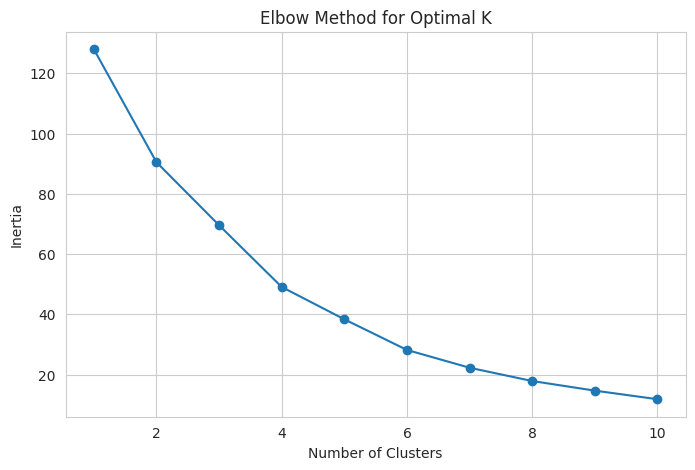

In [137]:
#### using elbow method to find the best num of clusters
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [138]:
#### training the model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

trader_features["Cluster"] = kmeans.fit_predict(scaled_features)

trader_features.head()

,Account,Total_Trades,Average_Trade_Size,Total_PnL,Win_Rate,Cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734,1.600230e+06,35.961236,3
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327,4.788532e+04,44.271978,0
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898,-7.043619e+04,30.191651,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933,1.324648e+05,43.858463,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782,1.686580e+05,51.991355,0


In [139]:
### summarizing each and every cluster
cluster_summary = (
    trader_features
    .groupby("Cluster")
    .agg(
        Traders=("Account", "count"),
        Avg_Trades=("Total_Trades", "mean"),
        Avg_Trade_Size=("Average_Trade_Size", "mean"),
        Avg_PnL=("Total_PnL", "mean"),
        Avg_WinRate=("Win_Rate", "mean")
    )
    .round(2)
)

cluster_summary

,Traders,Avg_Trades,Avg_Trade_Size,Avg_PnL,Avg_WinRate
Cluster,,,,,
0,12,3664.75,2841.68,175750.74,49.83
1,13,4820.15,4546.32,115092.80,31.74
2,3,25369.67,2964.19,1306542.32,41.10
3,4,7119.00,22539.72,693029.19,38.99


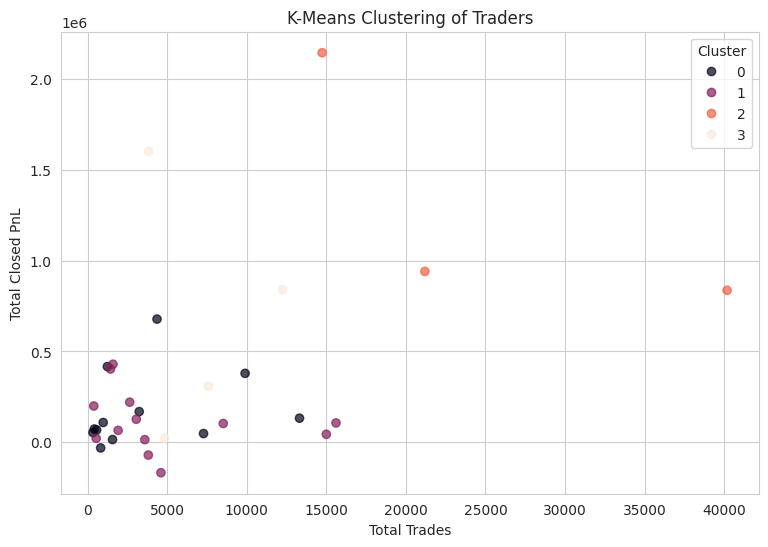

In [140]:
### visualizing the clusters
plt.figure(figsize=(9,6))

scatter = plt.scatter(
    trader_features["Total_Trades"],
    trader_features["Total_PnL"],
    c=trader_features["Cluster"],
    alpha=0.7
)

plt.xlabel("Total Trades")
plt.ylabel("Total Closed PnL")
plt.title("K-Means Clustering of Traders")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.grid(True)

plt.show()

##### Findings from the ML model:

## Cluster 0 — Consistent Traders
### Characteristics

- Highest Win Rate (49.83%)
- Moderate number of trades
- Small trade sizes
- Moderate profitability
### Interpretation
These traders appear to prioritize consistency over aggressive risk-taking. Their relatively high win rate and moderate profitability suggest a disciplined approach with controlled position sizing.

## Cluster 1 — Conservative Traders
### Characteristics
- Lowest Win Rate
- Moderate trade frequency
- Moderate trade sizes
- Lowest profitability
### Interpretation
This group achieved the weakest performance across the clusters. The combination of lower win rates and comparatively lower realized profits suggests that these traders may struggle with execution or risk management.

## Cluster 2 — High-Frequency Professionals
### Characteristics
- Highest number of trades
- Over 1.3 million average PnL
- Moderate trade size
- Solid win rate
### Interpretation
Although they do not have the highest win rate, these traders generated the greatest average profitability by participating in the market far more frequently than other groups. Their results indicate that sustained trading activity combined with disciplined execution can produce strong long-term performance.


## Cluster 3 — High-Stakes Traders
### Characteristics
- Largest average trade size
- Very high profitability
- Moderate trade frequency
- Average win rate
### Interpretation
These traders committed significantly more capital to each trade than any other cluster. Their strong profitability suggests that larger position sizes can enhance returns when supported by effective trade selection and risk management.

Overall Observations from the ML model:
- Observation 1: K-Means clustering successfully identified four distinct trader archetypes based on trading frequency, trade size, profitability, and win rate.

- Observation 2: The most profitable cluster was High-Frequency Professionals, who averaged over 25,000 trades and generated the highest realized PnL despite not having the highest win rate.

- Observation 3: The Consistent Traders cluster achieved the highest win rate but did not generate the highest profits, reinforcing an earlier finding that win rate alone is not the best indicator of trading success.

- Observation 4: The High-Stakes Traders cluster demonstrated that larger average position sizes were associated with stronger profitability. However, such an approach likely involves greater exposure to market risk.

- Observation 5: The clustering analysis shows that traders employ diverse strategies to achieve profitability. Some rely on frequent trading, while others focus on larger position sizes or consistent execution.

In [141]:
print('Analysis Completed Successfully')

Analysis Completed Successfully
